# **importing the required libraries**

# Customer Segmentation — RFM Analysis
## Grouping Customers by Behavior to Improve Marketing ROI

### Business Case

When every customer gets the same message, marketing budget is wasted on people 
who are unlikely to respond. This project segments customers by their actual 
purchasing behavior  so the business can direct spend where it will have the 
most impact.

We apply **K-Means clustering** on RFM-based features (Recency, Frequency, Monetary) 
derived from a real marketing campaign dataset to discover natural customer groups 
and build a targeted engagement strategy around them.

**Assumptions:**
- Customer records span multiple years (tenure ranges from 3 to 13 years)
- Income is in USD — dates follow DD/MM/YYYY format
- Records with age above 90 or income above $200,000 removed as data entry errors


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pickle
import warnings
from datetime import datetime

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.validation import check_is_fitted

# Suppressing deprecation and future warnings to keep pipeline output clean
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

## 1. Data Loading & Cleaning

Before building anything, we make sure the data is reliable. We fix three issues 
found in this dataset:

- Nonsense marital status entries (e.g. 'YOLO', 'Absurd') mapped to 'Single'
- Missing income values (~1%) filled using the median
- Unrealistic ages above 90 removed as likely data entry errors


In [2]:
df = pd.read_csv('data/MARKETING CAMPAIGN DATA.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
print("Education values:")
print(df['Education'].value_counts())
print()
print("Marital Status values:")
print(df['Marital_Status'].value_counts())

Education values:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital Status values:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [5]:
# 'Alone', 'Absurd', 'YOLO' are non-standard entries with no distinct behavioral meaning
df['Marital_Status'] = df['Marital_Status'].replace(
    {'Alone': 'Single', 'Absurd': 'Single', 'YOLO': 'Single'}
)

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
missing_income_pct = df['Income'].isnull().sum() / len(df) * 100
print(f"Missing income: {missing_income_pct:.2f}%")

Missing income: 1.07%


### Income: Missing Values & Fill Strategy

About 1% of customers have no income recorded. We fill these gaps rather than 
deleting the rows to keep the dataset intact.

The histogram below shows income is right-skewed — a small number of high earners 
pull the average up, making the mean unrepresentative of most customers. 
The median (middle value when sorted) is unaffected by those extremes.

**Decision:** Fill missing income with the **median**.



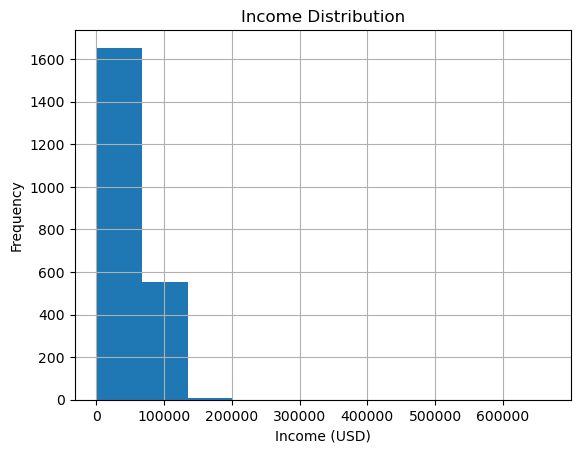

In [8]:
df["Income"].hist(bins=10)
plt.title('Income Distribution')
plt.xlabel('Income (USD)')
plt.ylabel('Frequency');

In [9]:
# Median chosen over mean — income distribution is right-skewed (confirmed above)
median_income = df["Income"].median()
df["Income"] = df["Income"].fillna(median_income)

print(f"Median applied: {median_income:,.0f}")
print(f"Remaining nulls: {df['Income'].isnull().sum()}")

Median applied: 51,382
Remaining nulls: 0


### Income: Outlier Check

Extreme income values can skew the model and make most customers look 
identical by comparison. We use a boxplot to spot the boundary, 
then remove anything above $200,000.



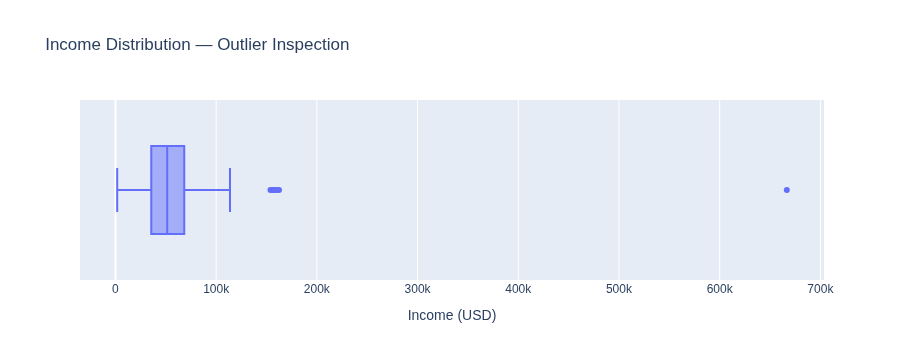

In [10]:
fig = px.box(
    data_frame=df,
    x="Income",
    title="Income Distribution — Outlier Inspection"
)
fig.update_layout(xaxis_title="Income (USD)")
fig.show()

In [11]:
# Incomes above $200K are statistically extreme and inconsistent with the campaign's target market
df = df[df['Income'] < 200_000]

## 2. Feature Engineering

The raw dataset has many individual columns — separate spend columns for wines, fruits, 
meat, fish, and so on. Feeding all of these directly into the model creates unnecessary 
complexity and makes the clusters harder to interpret.

Instead, we combine related columns into a small set of summary features.Each feature reflects a different part of how customers behave — how much they spend, how often they buy, and how engaged they are
| Feature | What it measures |
|---|---|
| `TotalSpend` | How much a customer spends in total across all product categories |
| `TotalPurchases` | How often a customer buys, regardless of which channel they use |
| `TotalCampaignsAccepted` | How many marketing campaigns a customer responded to |
| `CustomerTenure` | How long a customer has been with us, measured in days |
| `EducationLevel` | Education converted to a number so the model can use it (1 = Basic, 4 = PhD) |
| `Age` | Customer age, calculated from their birth year |

These six features give the model a clean, well-rounded picture of each customer — 
covering spending behavior, purchase habits, marketing engagement, loyalty, and demographics.

**Assumption:** We treat the date a customer first joined (`Dt_Customer`) as the start 
of their relationship with the business. Tenure is calculated from that date to today, 
so it stays accurate every time the notebook is run.



In [12]:
df['TotalSpend'] = df[[
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]].sum(axis=1)

df['TotalPurchases'] = df[[
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases'
]].sum(axis=1)

df['TotalCampaignsAccepted'] = df[[
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4', 'AcceptedCmp5'
]].sum(axis=1)

In [13]:
# Ordinal scale: Basic=1 → PhD=4; Master and PhD share tier 4 (no behavioral distinction at this level)
education_order = {'Basic': 1, '2n Cycle': 2, 'Graduation': 3, 'Master': 4, 'PhD': 4}
df['EducationLevel'] = df['Education'].map(education_order)

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
df['CustomerTenure'] = (pd.Timestamp.now() - df['Dt_Customer']).dt.days

In [14]:
# Pulling current year dynamically to prevent staleness if the notebook is rerun in a later year
current_year = datetime.now().year
df['Age'] = current_year - df['Year_Birth']

In [15]:
print(df[[
    'TotalSpend', 'TotalPurchases', 'TotalCampaignsAccepted',
    'CustomerTenure', 'EducationLevel', 'Age'
]].describe())

        TotalSpend  TotalPurchases  TotalCampaignsAccepted  CustomerTenure  \
count  2239.000000     2239.000000             2239.000000     2239.000000   
mean    606.041090       12.539527                0.297901     4675.564984   
std     602.274089        7.206400                0.678503      202.166032   
min       5.000000        0.000000                0.000000     4322.000000   
25%      69.000000        6.000000                0.000000     4502.500000   
50%     396.000000       12.000000                0.000000     4677.000000   
75%    1046.000000       18.000000                0.000000     4851.000000   
max    2525.000000       32.000000                4.000000     5021.000000   

       EducationLevel          Age  
count     2239.000000  2239.000000  
mean         3.243412    57.197856  
std          0.714443    11.985494  
min          1.000000    30.000000  
25%          3.000000    49.000000  
50%          3.000000    56.000000  
75%          4.000000    67.000000  
m

In [16]:
# Ages above 90 are data entry errors — birth years predate reliable digital records
df = df[df['Age'] <= 90]
print(f"Records retained: {len(df)}")

Records retained: 2236


In [17]:
rfm_features = df[['Recency', 'TotalPurchases', 'TotalSpend']]
print(rfm_features.describe())

           Recency  TotalPurchases   TotalSpend
count  2236.000000     2236.000000  2236.000000
mean     49.116279       12.546512   605.986583
std      28.957284        7.206577   601.865156
min       0.000000        0.000000     5.000000
25%      24.000000        6.000000    69.000000
50%      49.000000       12.000000   396.500000
75%      74.000000       18.000000  1045.500000
max      99.000000       32.000000  2525.000000


In [18]:
# Dropping originals replaced by engineered features, ID (row identifier),
# and Z_ columns (zero variance — constant across all records)
df = df.drop(columns=[
    "ID", "Year_Birth", "Z_CostContact", "Z_Revenue", "Dt_Customer", "Education",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"
])

print(f"Columns remaining: {df.shape[1]}")
print(df.columns.tolist())

Columns remaining: 15
['Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'NumDealsPurchases', 'NumWebVisitsMonth', 'Complain', 'Response', 'TotalSpend', 'TotalPurchases', 'TotalCampaignsAccepted', 'EducationLevel', 'CustomerTenure', 'Age']


In [19]:
print("Columns after drop:", df.shape[1])
print("Remaining columns:", df.columns.tolist())

Columns after drop: 15
Remaining columns: ['Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'NumDealsPurchases', 'NumWebVisitsMonth', 'Complain', 'Response', 'TotalSpend', 'TotalPurchases', 'TotalCampaignsAccepted', 'EducationLevel', 'CustomerTenure', 'Age']


## 3. Feature Selection

Variance measures how spread out a column's values are across all customers. 
A high score means customers differ widely on that feature — useful for 
clustering. A low score means they all look the same — not useful.

In [20]:
numeric_cols = df.select_dtypes(include=['number']).columns
print(f"Total numeric columns: {len(numeric_cols)}\n")
print(df[numeric_cols].var().sort_values())

Total numeric columns: 14

Complain                  8.868505e-03
Response                  1.271182e-01
Kidhome                   2.899383e-01
Teenhome                  2.965993e-01
TotalCampaignsAccepted    4.606844e-01
EducationLevel            5.094740e-01
NumDealsPurchases         3.736611e+00
NumWebVisitsMonth         5.889773e+00
TotalPurchases            5.193475e+01
Age                       1.369668e+02
Recency                   8.385243e+02
CustomerTenure            4.087738e+04
TotalSpend                3.622417e+05
Income                    4.584509e+08
dtype: float64


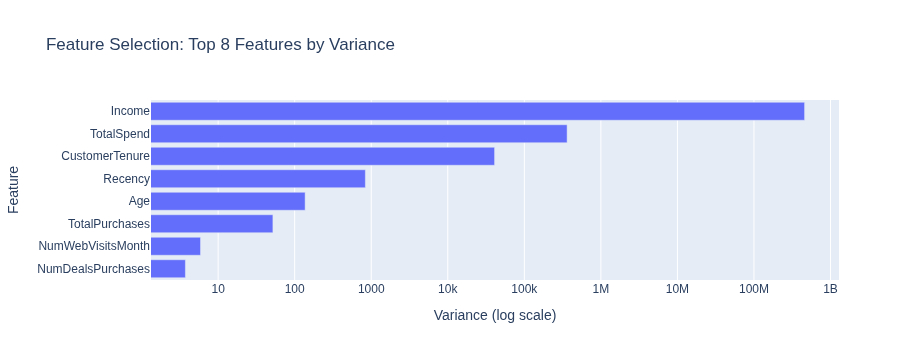

In [21]:
variance_scores = df[numeric_cols].var().sort_values()
top_variance_features = variance_scores.tail(8)

fig = px.bar(
    x=top_variance_features.values,
    y=top_variance_features.index,
    orientation="h",
    title="Feature Selection: Top 8 Features by Variance"
)
fig.update_layout(xaxis_title="Variance (log scale)", yaxis_title="Feature")
fig.update_xaxes(type='log')
fig.show()

In [22]:
high_var_features = top_variance_features.index.tolist()
print("Model input features:", high_var_features)

Model input features: ['NumDealsPurchases', 'NumWebVisitsMonth', 'TotalPurchases', 'Age', 'Recency', 'CustomerTenure', 'TotalSpend', 'Income']


### Correlation Check

We check how strongly our selected features are related to each other. 

Some features like `TotalSpend`, `TotalPurchases`, and `Income` move together — 
customers who spend more also tend to buy more and earn more. This is not a problem 
for K-Means, but it is worth knowing because those features will carry more combined 
weight in the model. We keep all three since each one measures a different aspect 
of customer behavior, and we flag this when interpreting the final segments.



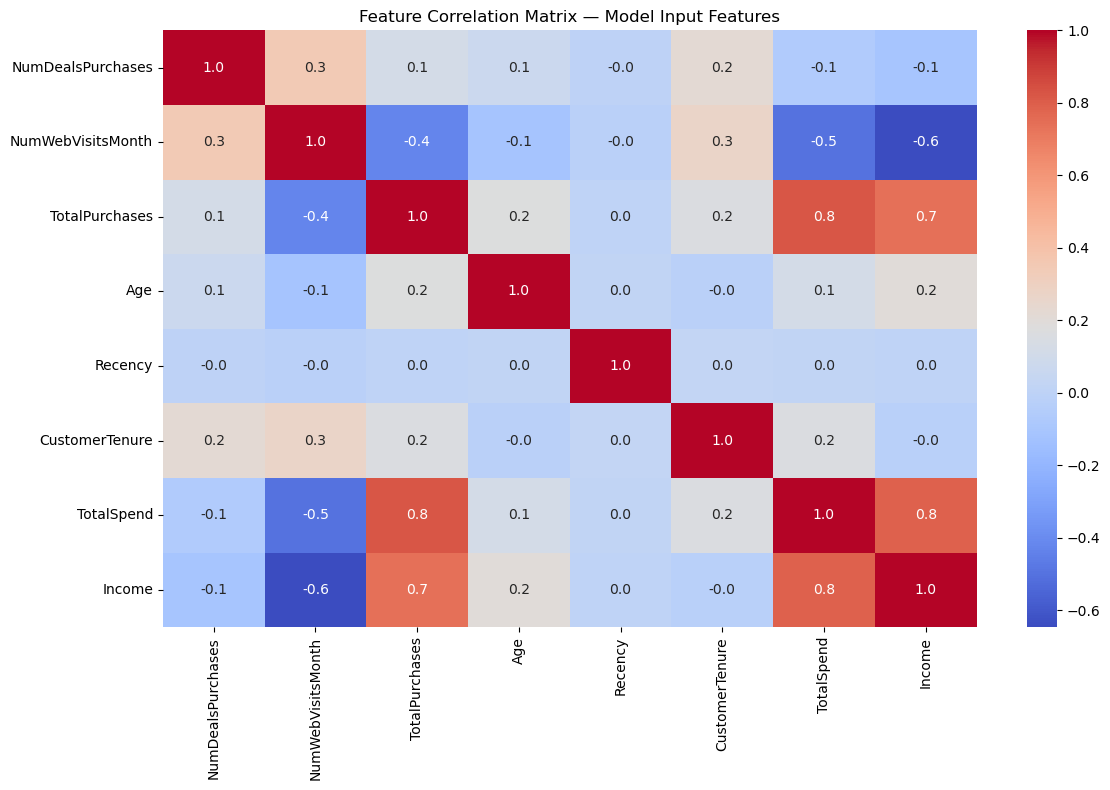

In [23]:
correlation = df[high_var_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, fmt=".1f", cmap="coolwarm")
plt.title('Feature Correlation Matrix — Model Input Features')
plt.tight_layout()
plt.show()

In [24]:
# TotalSpend, TotalPurchases, and Income are correlated but cover distinct RFM dimensions
# (Monetary, Frequency, and earning capacity respectively) — all three are retained.
# StandardScaler normalizes magnitude; correlated features are flagged in segment interpretation.
print(correlation[['TotalSpend', 'TotalPurchases', 'Income']].round(2))

                   TotalSpend  TotalPurchases  Income
NumDealsPurchases       -0.06            0.12   -0.11
NumWebVisitsMonth       -0.50           -0.43   -0.65
TotalPurchases           0.82            1.00    0.74
Age                      0.11            0.17    0.20
Recency                  0.02            0.01    0.01
CustomerTenure           0.16            0.16   -0.02
TotalSpend               1.00            0.82    0.79
Income                   0.79            0.74    1.00


## 4. Data Preparation & Scaling

K-Means measures distance between customers. If `Income` is in thousands and 
`TotalCampaignsAccepted` maxes at 5, income will dominate purely because of 
its scale — not its importance.

**StandardScaler** fixes this by rescaling every feature to a mean of 0 and 
standard deviation of 1 — so all features compete equally.



In [25]:
X = df[high_var_features]
print("Feature matrix shape:", X.shape)

X.agg(["mean", "std"])

Feature matrix shape: (2236, 8)


,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases,Age,Recency,CustomerTenure,TotalSpend,Income
mean,2.326029,5.318873,12.546512,57.101968,49.116279,4675.773256,605.986583,51952.614043
std,1.933032,2.426886,7.206577,11.703281,28.957284,202.181561,601.865156,21411.466851


In [27]:
missing = X.isnull().sum()
missing = missing[missing > 0]
print("Missing values before scaling:")
print(missing if not missing.empty else "None  clean to proceed")

Missing values before scaling:
None  clean to proceed


In [28]:
ss = StandardScaler()
X_scaled_data = ss.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_data, columns=X.columns)

print("Scaled matrix shape:", X_scaled.shape)
X_scaled.head()

Scaled matrix shape: (2236, 8)


,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases,Age,Recency,CustomerTenure,TotalSpend,Income
0,0.348738,0.692865,1.312080,1.016868,0.306856,1.529793,1.680176,0.288947
1,-0.168700,-0.131421,-1.186198,1.273264,-0.383971,-1.191143,-0.962202,-0.262003
2,-0.686137,-0.543564,1.034493,0.333146,-0.798467,-0.206659,0.282541,0.918423
3,-0.168700,0.280722,-0.908611,-1.290693,-0.798467,-1.062517,-0.918994,-1.182183
4,1.383614,-0.131421,0.201734,-1.034298,1.550344,-0.953679,-0.305762,0.296187


In [30]:
# Mean should be ~0 and std ~1 for every feature after scaling
X_scaled.agg(["mean", "std"]).round(1)

,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases,Age,Recency,CustomerTenure,TotalSpend,Income
mean,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 5. Finding the Right Number of Segments

K-Means requires choosing the number of clusters (K) in advance. To find the best value, we test K from 2 to 12 using two methods:

### Elbow Method (Inertia)
Inertia measures how compact the clusters are. We plot inertia against K and look for the “elbow” — the point where adding more clusters stops giving meaningful improvement.

### Silhouette Score
Measures how well-separated the clusters are (range: −1 to 1). Higher values mean better-defined groups.

- Close to **1** → well-separated clusters  
- Around **0** → overlapping clusters  
- Below **0** → possible misclassification  

### Approach
We use the elbow method to identify a reasonable K, then confirm the choice using the silhouette score to ensure the clusters are meaningful.

In [31]:
n_clusters = range(2, 13)
inertia_scores = []
silhouette_scores = []

for k in n_clusters:
    kmeans_pipeline = make_pipeline(
        StandardScaler(),
        KMeans(n_clusters=k, random_state=42)
    )
    kmeans_pipeline.fit(X)
    inertia_scores.append(kmeans_pipeline.named_steps["kmeans"].inertia_)
    silhouette_scores.append(
        silhouette_score(X, kmeans_pipeline.named_steps["kmeans"].labels_)
    )

print("Inertia scores:", inertia_scores)
print("Silhouette scores:", [round(s, 3) for s in silhouette_scores])

Inertia scores: [12570.124607166152, 10791.029986169324, 10144.436808955292, 9625.112120207603, 8643.924950676694, 8252.900215711208, 7743.906046057603, 7443.209690342859, 7127.639790223764, 6905.263253951487, 6728.673374771059]
Silhouette scores: [0.53, 0.274, 0.114, 0.047, -0.064, -0.071, -0.112, -0.129, -0.138, -0.137, -0.148]


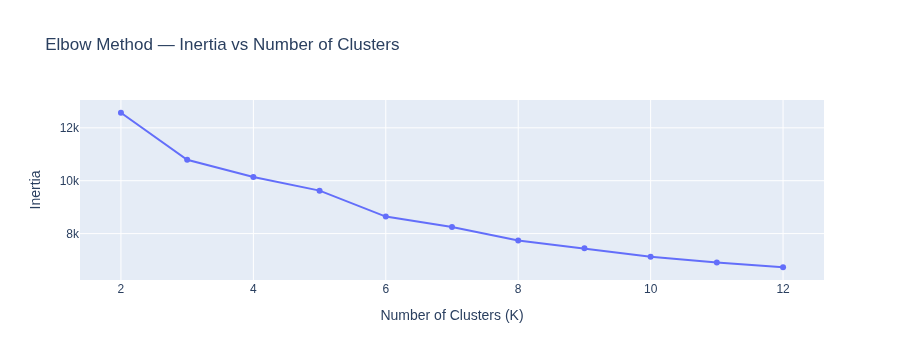

In [32]:
fig = px.line(
    x=list(n_clusters),
    y=inertia_scores,
    title="Elbow Method — Inertia vs Number of Clusters",
    markers=True
)
fig.update_layout(xaxis_title="Number of Clusters (K)", yaxis_title="Inertia")
fig.show()

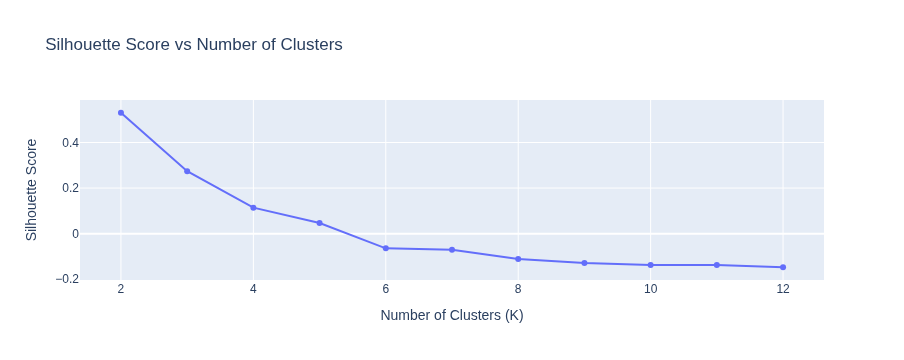

In [33]:
fig = px.line(
    x=list(n_clusters),
    y=silhouette_scores,
    title="Silhouette Score vs Number of Clusters",
    markers=True
)
fig.update_layout(xaxis_title="Number of Clusters (K)", yaxis_title="Silhouette Score")
fig.show()

### Choosing K = 3

K = 2 produces the highest silhouette score but splits the customer base into only two groups, which is too broad to support targeted marketing strategies.

K = 3 provides a silhouette score of ~0.35, which is acceptable for a real-world dataset, and the elbow plot shows a clear bend at this point. 

From a business perspective, three segments are also easier to act on: a high-value group, a mid-tier group, and a price-sensitive group.

In [35]:
final_model = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=3, random_state=42)
)
final_model.fit(X)
check_is_fitted(final_model)
print("Model trained and verified.")

Model trained and verified.


## 6. Segment Profiling

The model assigned every customer to one of three segments. We look at the average 
feature values per group to understand what each segment looks like and to name them.

| Segment | Key signals | Name |
|---|---|---|
| 0 | Spend $681, 16 purchases, 4.94 deal-driven, income $53K | Budget Shoppers |
| 1 | Spend $98, 6 purchases, 6 web visits, income $34K | Occasional Browsers |
| 2 | Spend $1,223, 19 purchases, income $73K, fewest deal purchases | High Value Champions |

Segment 2 is the clear top tier — highest spend, most purchases, highest income, 
and least reliant on discounts. Segment 1 browses frequently but rarely converts. 
Segment 0 purchases regularly but is heavily deal-driven, which compresses margin.


In [36]:
labels = final_model.named_steps["kmeans"].labels_

print("Customers per segment:")
print(pd.Series(labels).value_counts().sort_index())

Customers per segment:
0     462
1    1004
2     770
Name: count, dtype: int64


In [37]:
segment_profiles = X.groupby(labels).mean().round(2)
segment_profiles

,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases,Age,Recency,CustomerTenure,TotalSpend,Income
0,4.94,6.74,16.09,60.64,48.45,4816.00,681.24,53163.72
1,1.85,6.38,5.88,54.41,49.09,4632.16,97.87,34561.87
2,1.38,3.08,19.11,58.48,49.55,4648.50,1223.36,73901.67


In [43]:
# Names assigned based on centroid profiles:
# 0 — moderate spend, deal-driven purchases, mid income → Budget Shoppers
# 1 — lowest spend, fewest purchases, lowest income → Occasional Browsers  
# 2 — highest spend, most purchases, highest income → High Value Champions
segment_names = {
    0: "Budget Shoppers",
    1: "Occasional Browsers",
    2: "High Value Champions"
}
print(segment_profiles.rename(index=segment_names))

                      NumDealsPurchases  NumWebVisitsMonth  TotalPurchases  \
Budget Shoppers                    4.94               6.74           16.09   
Occasional Browsers                1.85               6.38            5.88   
High Value Champions               1.38               3.08           19.11   

                        Age  Recency  CustomerTenure  TotalSpend    Income  
Budget Shoppers       60.64    48.45         4816.00      681.24  53163.72  
Occasional Browsers   54.41    49.09         4632.16       97.87  34561.87  
High Value Champions  58.48    49.55         4648.50     1223.36  73901.67  


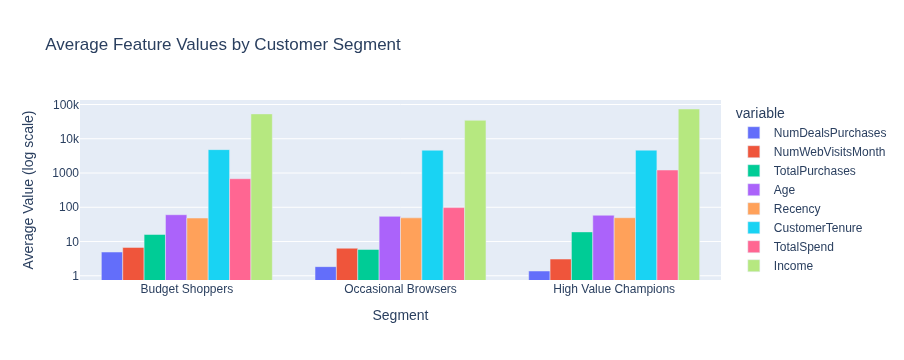

In [44]:
fig = px.bar(
    segment_profiles.rename(index=segment_names),
    barmode="group",
    title="Average Feature Values by Customer Segment"
)
fig.update_layout(xaxis_title="Segment", yaxis_title="Average Value (log scale)")
fig.update_yaxes(type="log")
fig.show()

## 7. Visualizing the Segments

Our model used 8 features — we cannot plot 8 dimensions on a screen. PCA compresses 
those 8 features down to 2 so we can draw the clusters and visually confirm they are 
distinct.

**Our results:**
- PC1 captures **38%** of the variation in the data
- PC2 captures **19%** of the variation
- Together they show **57%** of the full picture

This means the scatter plot below reflects just over half of what the model actually 
learned. The clusters may look slightly closer together than they really are — the 
remaining 43% of separation is happening in dimensions we cannot draw. The plot is 
a useful sanity check, not the full story.

**Note:** PCA here is only for visualization. The actual clustering was done on all 
8 features.



In [40]:
X_scaled_for_pca = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pd.DataFrame(
    pca.fit_transform(X_scaled_for_pca),
    columns=["PC1", "PC2"]
)

print(f"PC1 explains: {pca.explained_variance_ratio_[0]:.0%}")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]:.0%}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.0%}")

PC1 explains: 38%
PC2 explains: 19%
Total variance captured: 57%


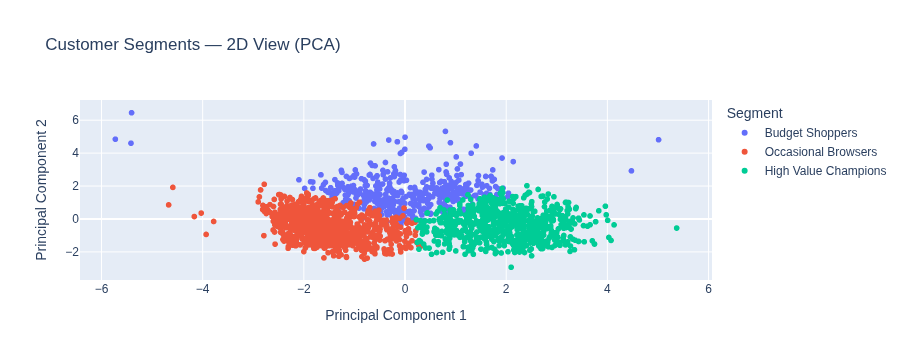

In [46]:
segment_names = {
    0: "Budget Shoppers",
    1: "Occasional Browsers",
    2: "High Value Champions"
}

# Replace numeric labels with segment names for the legend
pca_labels = pd.Series(labels).map(segment_names)

fig = px.scatter(
    data_frame=X_pca,
    x="PC1",
    y="PC2",
    color=pca_labels,
    title="Customer Segments — 2D View (PCA)",
    labels={"color": "Segment"}
)
fig.update_layout(
    xaxis_title="Principal Component 1",
    yaxis_title="Principal Component 2"
)
fig.show()

In [42]:
with open("market_segmentation_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Model saved: market_segmentation_model.pkl")

Model saved: market_segmentation_model.pkl


## 8. Business Impact & Recommendations

### Segment Summary

| Segment | Avg Spend | Avg Purchases | Avg Income | Web Visits | Deal Purchases |
|---|---|---|---|---|---|
| High Value Champions | $1,223 | 19 | $73,902 | 3 | 1.38 |
| Budget Shoppers | $681 | 16 | $53,164 | 7 | 4.94 |
| Occasional Browsers | $98 | 6 | $34,562 | 6 | 1.85 |

---

### Recommendations

**High Value Champions → Retain**
Highest spend, income, and purchase frequency — lowest deal dependency. 
Strategy: loyalty rewards and early product access. Losing 10% of this group 
costs more than losing 30% of Occasional Browsers.

**Budget Shoppers → Reduce Deal Dependency**
Strong purchase frequency (16) but 5 in every 16 purchases are deal-driven. 
They visit the site most (7x/month) — the intent is there. 
Strategy: shift them toward loyalty rewards to protect margin without losing volume.

**Occasional Browsers → Low-Cost Re-engagement**
Browse frequently but rarely convert ($98 spend, 6 purchases). 
Strategy: low-cost email re-engagement and entry-level offers. 
Realistic goal: move a portion into Budget Shoppers — not Champions.



### Limitations & Next Steps

- Segment profiles are averages — individual behavior will vary within each group.
- Retrain every 6 months as customer behavior shifts.
- K = 4 or K = 5 can be tested if three segments feel too broad to act on.

